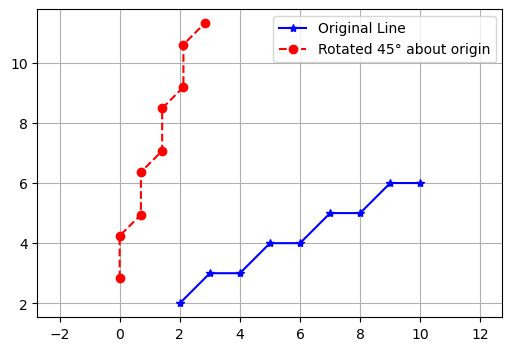

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Bresenham Line Algorithm ---
def bresenham_line(x0, y0, x1, y1):
    xes, yes = [], []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x1 >= x0 else -1
    sy = 1 if y1 >= y0 else -1
    x, y = x0, y0
    if dx >= dy:
        p = 2 * dy - dx
        for _ in range(dx + 1):
            xes.append(x)
            yes.append(y)
            x += sx
            if p >= 0:
                y += sy
                p += 2 * dy - 2 * dx
            else:
                p += 2 * dy
    else:
        p = 2 * dx - dy
        for _ in range(dy + 1):
            xes.append(x)
            yes.append(y)
            y += sy
            if p >= 0:
                x += sx
                p += 2 * dx - 2 * dy
            else:
                p += 2 * dx
    return np.array(xes), np.array(yes)

# --- Q3: Pure rotation about the origin ---
def rotate_about_origin(x0, y0, x1, y1, theta_deg):
    x_orig, y_orig = bresenham_line(x0, y0, x1, y1)  # Use Bresenham line

    # Convert degrees to radians
    theta = np.deg2rad(theta_deg)
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])

    # Homogeneous coordinates
    points = np.vstack([x_orig, y_orig, np.ones_like(x_orig)])
    rotated_points = rotation_matrix @ points

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(x_orig, y_orig, '*-b', label='Original Line')
    plt.plot(rotated_points[0], rotated_points[1], 'o--r', label=f'Rotated {theta_deg}° about origin')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# --- Example usage ---
rotate_about_origin(2, 2, 10, 6, 45)
